CAMPI DI APPLICAZIONE: DALLA CREATIVITA' ALLA DIAGNOSTICA INDUSTRIALE

I modelli generativi non servono solo a creare immagini o testo. La stessa logica, apprendere la struttura dei dati e generare o ricostruire esempi plausibili, ha applicazoni che vanno dalla creatività fino al contorollo qualità e manutenzione industriale.

1) CREATIVITA' E PRODUZIONE DI CONTENUTI
    E' il più visibile
    Può produrre: testo, immagini, musica, video, audio, modelli 3d, codici
    Esempio: "cre l'immagine di una cucina industriale moderna" - > modello generativo -> nuova immagine
    Applicazioni: marketing, advertising, concept design, videogiochi, cinema, prototipazione, copywriting, grafica
    Il vantaggio principale non è soltanto creare ma ridurre, drasticamente, il tempo tra idea e prototipo

2) GENERAZIONE TESTO
    Qui rientrano gli LLM
    Applicazioni: email, report, riassunti, manuali, FAQ, documentazione, traduzioni, codice.
    In azienda però farei una distinzione.
    Un LLM potrebbe essere utile per:
        "spiegami perchè questo ordine è bloccato"
    meno appropriato per
        "calcola il totale della fattura"
    Il secondo richede logica deterministica, questa distinzione è fondamentale nei sistemi ERP

3) GENERAZIONE CODICE
    I modelli generativi possono produrre codice SQL, codice Python, ecc 
    Ma il codice generato deve essere validato
    Un modello può produrre SQL sintatticamente corretto, ma logicamente sbagliato.
    Usi: generazione codice, test automatici, documentazione, spiegazione codice

4) DATI SINTETICI
    Il modello può imparare la distribuzione dei dati e generare dati simili.
    Questi dati possono essere usati per: test, sviluppo, simulazioni, pricavy.
    Es. quando non vuoi dasre i dati reali di un cliente e fare test su dati "inventati"

5) DATA AUGMENTATION
    Molto utilizzata in Computer Vision
    Un modello generativo può creare nuove immagini plausibili per poter poi addestrare meglio un classificatore
    Utilizzabile anche quando abbiamo un dataset sbilanciato, es. pezzi con difetti quando si vuole costruire un modello per classificare gli articoli tra ok qualità e ko qualità (con difetti)

7) DIAGNOSTICA INDUSTRIALE
    Lo stesso concetto al punto 6 può essere utilizzato non alle immagini ma ai sensori.
    Supponiamo di monitorare, per un motore, la temperatura, la pressione, le vibrazioni, la corrente, la velocità, il rumore.
    Durante il funzionamento 'normale' abbiamo dei dati, il modello impare la distribuzione del comportamento normale. Poi arrivano nuovi dati, se questi sono molto lontani dal comportamento appreso, allora ANOMALIA.
    Avvisa che il valore potrebbe essere sospetto

8) PREDICTIVE MAINTENANCE
    La manutenzione predittiva può usare algoritmi non di AI generativa, non serve necessariamente un modello generativo. Il modello generativo è interessante quando vogliamo imparare il comportamento 'normale' della macchina e confrontarlo con il comportamento osservato. Una deviazione significativa può indicare: usura, malfunzionamento, anomalia

9) DIGITAL TWIN
    Un Ditigal Twin è una rappresentazione digitale di un sisetma reale.
    macchina reale -> sensori -> modello digitale
    Il modello digitale può simulare:
        - cosa succede se aumento la velocità?
        - cosa succede se cambio la temperatura?
        - cosa succede con maggiore carico?
        - ecc

10) FARMACEUTICA E BIOLOGIA
    I modelli generativi vengono utilizzati anche per creare nuove strutture molecolari. Il modello non scopre 'automaticamente' un farmaco, genera candidati, poi servono simulazioni, test in laboratorio, studi clinici, validazione

11) MEDICAL IMAGIN
    Analizzare immagini mediche

12) GENERAZIONE SCENARI FINANZIARI
    un modello può apprendere distribuzioni di vendita, di domanza, di prezzi, di volumi e generare scenari

DIAMO AL MODELLO SOLO DATI 'NORMALI' QUANDO ARRIVA UN DATO 'NON NORMALE' ALZA LA MANO, possiamo prevedere la manutazione preventiva

Inizio addestramento: il modello sta apprendendo la struttura dei dati normali...


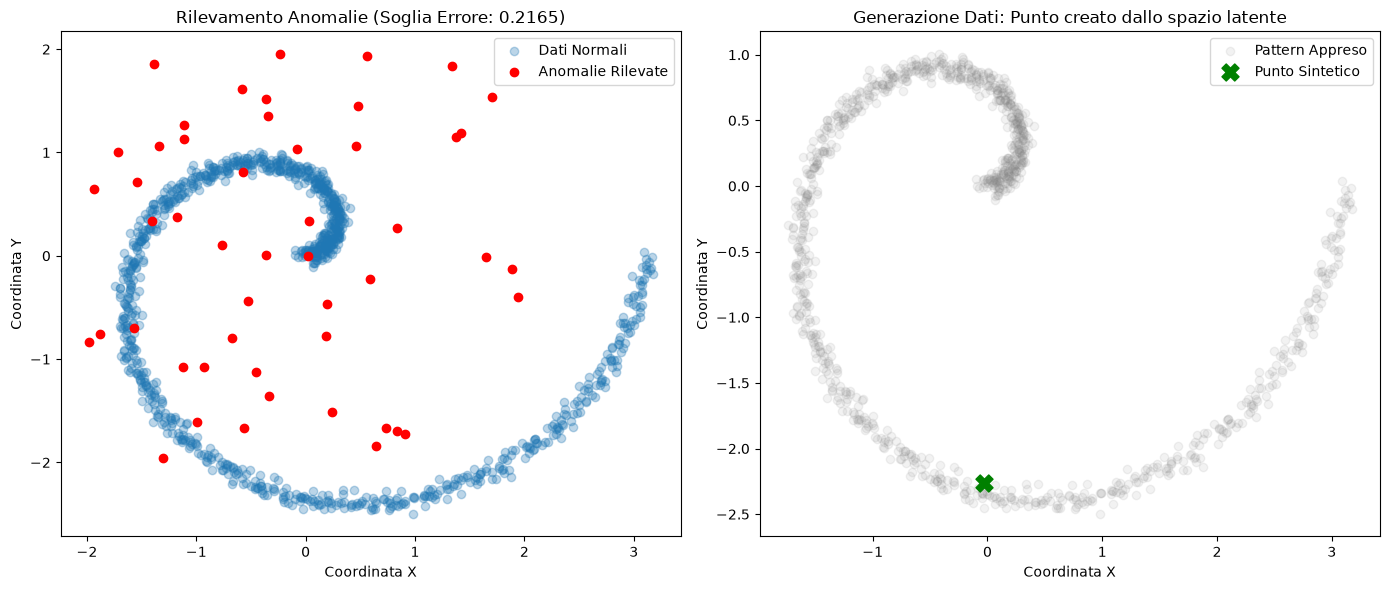

Processo completato. Punto sintetico generato alle coordinate: [[-0.02616903 -2.2637408 ]]


In [2]:
import os

# Impostazione del backend di Keras. Utilizziamo PyTorch come motore di calcolo sottostante.
# Questa configurazione deve avvenire prima di importare keras per avere effetto.
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers, ops
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PREPARAZIONE DEL DATASET ---
# In questo scenario simuliamo un processo produttivo industriale. 
# I dati "normali" seguono una struttura a spirale, mentre le "anomalie" sono punti casuali fuori pattern.

def get_data(n_samples=1000):
    """
    Genera un dataset sintetico composto da una spirale (normale) e punti sparsi (anomalie).
    """
    # Generazione della coordinata temporale/angolare
    theta = np.linspace(0, 2*np.pi, n_samples)
    # Definizione del raggio che cresce linearmente con l'angolo
    r = theta * 0.5
    
    # Creazione dei Dati Normali: aggiungiamo del rumore gaussiano per simulare variabilità naturale
    x = r * np.cos(theta) + np.random.normal(0, 0.05, n_samples)
    y = r * np.sin(theta) + np.random.normal(0, 0.05, n_samples)
    
    # Uniamo x e y in una matrice di coppie di coordinate (n_samples, 2)
    normal_data = np.stack([x, y], axis=1).astype("float32")
    
    # Generazione delle Anomalie: punti distribuiti uniformemente nello spazio che non seguono la spirale
    anomalies = np.random.uniform(-2, 2, (50, 2)).astype("float32")
    
    return normal_data, anomalies

# Esecuzione della funzione per ottenere i dati di addestramento e i test case anomali
data_train, anomalies = get_data()

# --- 2. ARCHITETTURA DEL MODELLO (Autoencoder) ---
# Un autoencoder è composto da due parti: un Encoder che comprime i dati e un Decoder che tenta di ricostruirli.
# Se il modello impara bene la struttura dei dati normali, fallirà nel ricostruire dati che non ha mai visto (anomalie).

# Definizione del punto di ingresso: un vettore con 2 caratteristiche (x, y)
inputs = keras.Input(shape=(2,), name="input_data")

# ENCODER: Riduzione della dimensionalità
# Il primo layer denso espande le caratteristiche per catturare relazioni non lineari.
encoder_hidden = layers.Dense(16, activation="relu")(inputs)
# Il layer 'latent_space' riduce tutto a un solo valore. Questa è la "essenza" del dato originale.
latent = layers.Dense(1, name="latent_space")(encoder_hidden)

# DECODER: Ricostruzione del dato originale
# Partendo dallo spazio latente, cerchiamo di tornare alla forma (x, y) iniziale.
decoder_hidden = layers.Dense(16, activation="relu")(latent)
# L'output ha dimensione 2 per corrispondere alle coordinate x e y originali.
outputs = layers.Dense(2, name="reconstruction")(decoder_hidden)

# Creazione dell'oggetto Modello che collega input ed output
autoencoder = keras.Model(inputs=inputs, outputs=outputs, name="Industrial_Autoencoder")

# Compilazione: usiamo l'ottimizzatore Adam e la funzione di perdita Mean Squared Error (MSE),
# ideale per confrontare quanto la ricostruzione differisce dall'originale.
autoencoder.compile(optimizer="adam", loss="mse")

# --- 3. ADDESTRAMENTO ---
# Il modello viene addestrato esclusivamente sui dati normali.
# In questo modo, "impara" a ricostruire perfettamente solo la spirale.
print("Inizio addestramento: il modello sta apprendendo la struttura dei dati normali...")
autoencoder.fit(data_train, data_train, epochs=50, batch_size=32, verbose=0)

# --- 4. RILEVAMENTO DELLE ANOMALIE ---
# Per identificare un'anomalia, calcoliamo l'errore tra il dato originale e quello ricostruito dal modello.

# Otteniamo le ricostruzioni per entrambi i set di dati
reconstructed_normal = autoencoder.predict(data_train, verbose=0)
reconstructed_anomalies = autoencoder.predict(anomalies, verbose=0)

# Calcolo del Mean Squared Error (MSE) riga per riga
# Un errore elevato indica che il modello non è riuscito a ricostruire bene il punto (quindi è un'anomalia).
mse_normal = np.mean(np.power(data_train - reconstructed_normal, 2), axis=1)
mse_anomalies = np.mean(np.power(anomalies - reconstructed_anomalies, 2), axis=1)

# Definiamo una soglia critica: usiamo il 95° percentile degli errori sui dati normali.
# Ogni punto con un errore superiore a questa soglia viene classificato come anomalia.
threshold = np.percentile(mse_normal, 95)

# --- 5. GENERAZIONE DI DATI SINTETICI ---
# Poiché abbiamo una rappresentazione compressa (spazio latente), possiamo "inventare" nuovi dati
# inserendo valori arbitrari nella sezione Decoder del modello.

# Definiamo un valore arbitrario nello spazio latente (1D)
fake_latent_point = np.array([[1.5]], dtype="float32")

# Creiamo un modello 'Generatore' isolando solo gli ultimi due layer (il decoder) dell'autoencoder.
gen_input = keras.Input(shape=(1,))
# Recuperiamo i layer per indice: il penultimo (Dense 16) e l'ultimo (Dense 2)
gen_out = autoencoder.layers[-2](gen_input)
gen_out = autoencoder.layers[-1](gen_out)
generator = keras.Model(gen_input, gen_out)

# Generiamo il punto fisico corrispondente al valore latente 1.5
synthetic_point = ops.convert_to_numpy(generator(fake_latent_point))

# --- 6. VISUALIZZAZIONE DEI RISULTATI ---
plt.figure(figsize=(14, 6))

# Primo grafico: Analisi delle anomalie
plt.subplot(1, 2, 1)
plt.scatter(data_train[:,0], data_train[:,1], alpha=0.3, label="Dati Normali")
plt.scatter(anomalies[:,0], anomalies[:,1], color='red', label="Anomalie Rilevate")
plt.title(f"Rilevamento Anomalie (Soglia Errore: {threshold:.4f})")
plt.xlabel("Coordinata X")
plt.ylabel("Coordinata Y")
plt.legend()

# Secondo grafico: Generazione di nuovi dati
plt.subplot(1, 2, 2)
plt.scatter(data_train[:,0], data_train[:,1], alpha=0.1, color='gray', label="Pattern Appreso")
plt.scatter(synthetic_point[:,0], synthetic_point[:,1], color='green', s=150, marker='X', label="Punto Sintetico")
plt.title("Generazione Dati: Punto creato dallo spazio latente")
plt.xlabel("Coordinata X")
plt.ylabel("Coordinata Y")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Processo completato. Punto sintetico generato alle coordinate: {synthetic_point}")